In [1]:
!pip install kaggle


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Load
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print(f" Matches: {matches.shape}")
print(f" Deliveries: {deliveries.shape}")
matches.head()

 Matches: (636, 18)
 Deliveries: (150460, 21)


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,5/4/2017,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,6/4/2017,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,7/4/2017,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,8/4/2017,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,8/4/2017,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


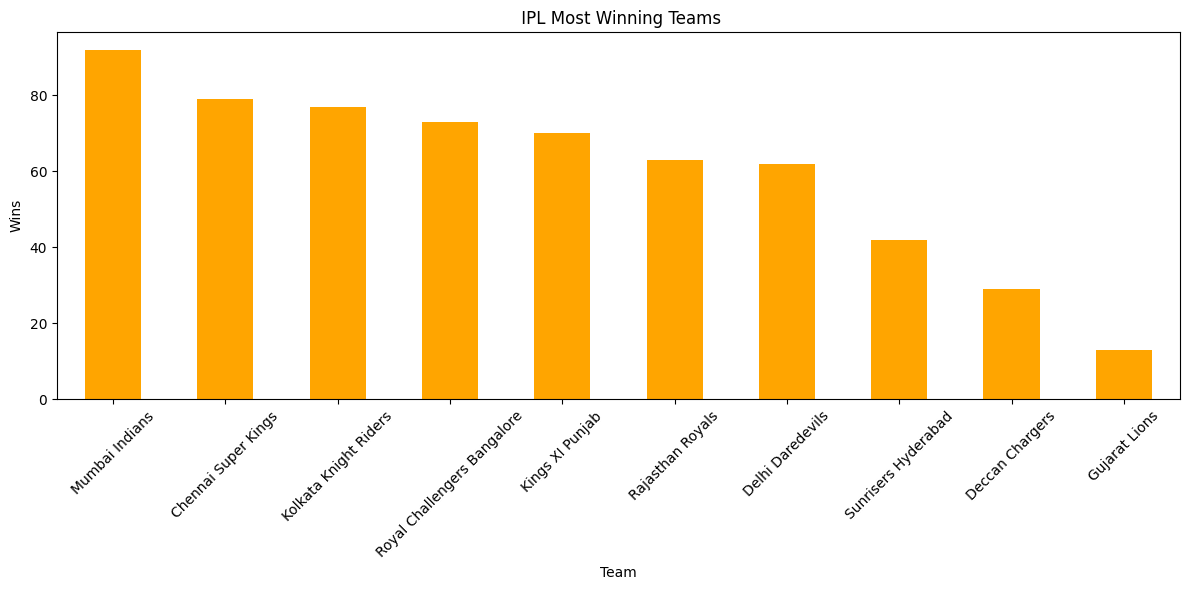

In [5]:
plt.figure(figsize=(12,6))
matches['winner'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title(' IPL Most Winning Teams')
plt.xlabel('Team')
plt.ylabel('Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

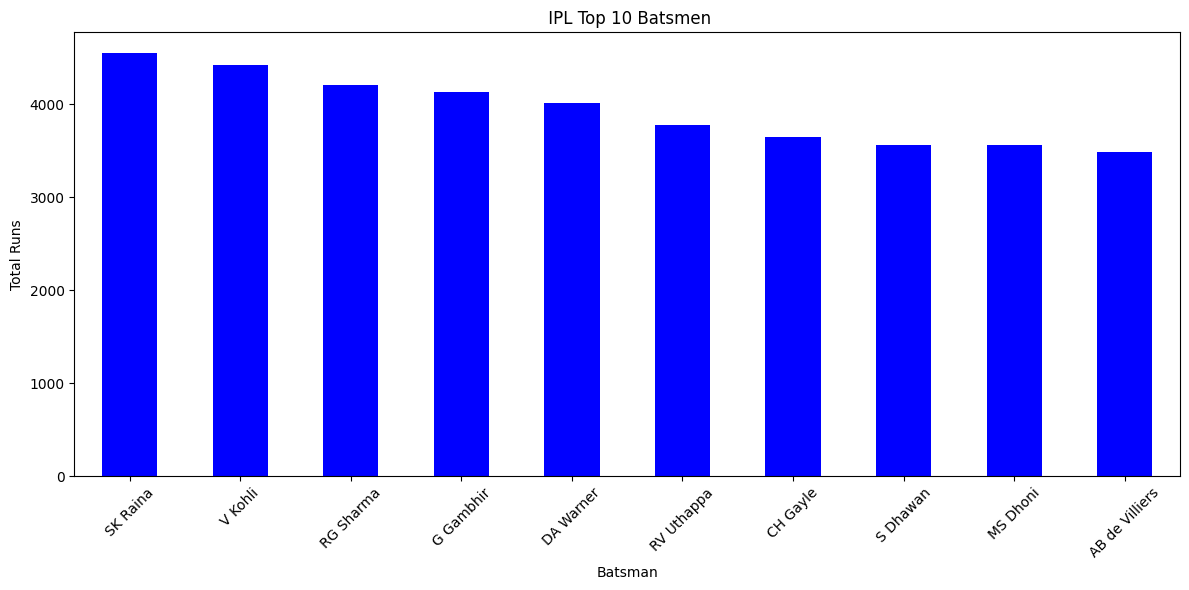

In [6]:
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum()
top_batsmen = top_batsmen.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_batsmen.plot(kind='bar', color='blue')
plt.title(' IPL Top 10 Batsmen')
plt.xlabel('Batsman')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_6577/1326824580.py:11: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


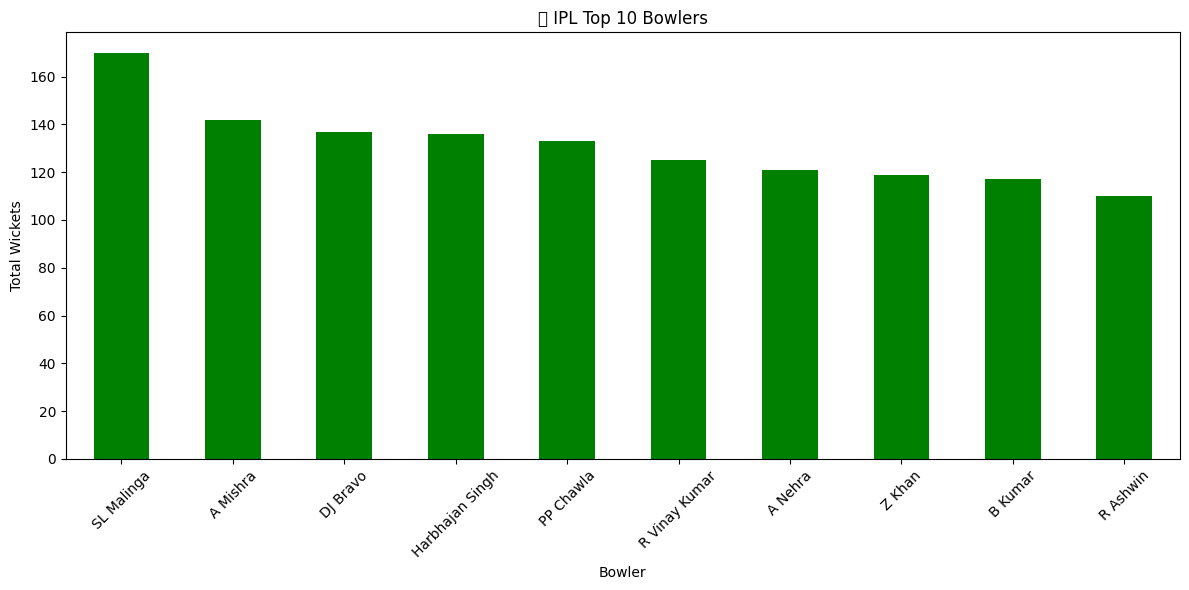

In [7]:
top_bowlers = deliveries[deliveries['dismissal_kind'].notna()]
top_bowlers = top_bowlers.groupby('bowler')['dismissal_kind'].count()
top_bowlers = top_bowlers.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
top_bowlers.plot(kind='bar', color='green')
plt.title(' IPL Top 10 Bowlers')
plt.xlabel('Bowler')
plt.ylabel('Total Wickets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/tmp/ipykernel_6577/1446826437.py:9: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


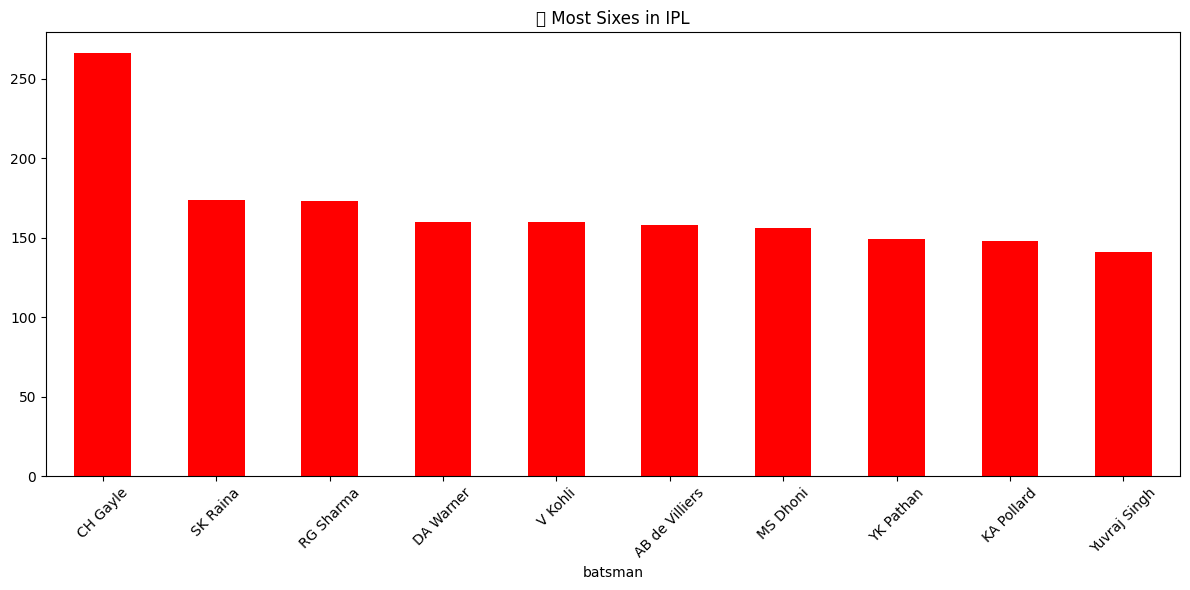

In [8]:
sixes = deliveries[deliveries['batsman_runs'] == 6]
sixes = sixes.groupby('batsman')['batsman_runs'].count()
sixes = sixes.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sixes.plot(kind='bar', color='red')
plt.title(' Most Sixes in IPL')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

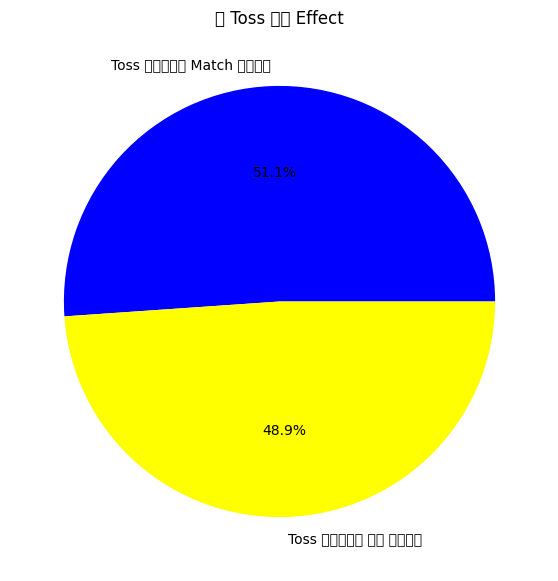

In [11]:
toss_win = matches[matches['toss_winner'] == matches['winner']]
labels = ['Toss जीतकर Match जीते', 'Toss जीतकर भी हारे']
sizes = [len(toss_win), len(matches) - len(toss_win)]

plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['Blue','yellow'])
plt.title('🪙 Toss का Effect')
plt.show()

In [12]:
!pip install plotly dash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 55.1 MB/s eta 0:00:00


In [18]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Data Load
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

# ============ DATA PREPARE ============

# Most Winning Teams
top_teams = matches['winner'].value_counts().head(10).reset_index()
top_teams.columns = ['Team', 'Wins']

# Top Batsmen
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum()
top_batsmen = top_batsmen.sort_values(ascending=False).head(10).reset_index()
top_batsmen.columns = ['Batsman', 'Runs']

# Top Bowlers
top_bowlers = deliveries[deliveries['dismissal_kind'].notna()]
top_bowlers = top_bowlers.groupby('bowler')['dismissal_kind'].count()
top_bowlers = top_bowlers.sort_values(ascending=False).head(10).reset_index()
top_bowlers.columns = ['Bowler', 'Wickets']

# Most Sixes
sixes = deliveries[deliveries['batsman_runs'] == 6]
sixes = sixes.groupby('batsman')['batsman_runs'].count()
sixes = sixes.sort_values(ascending=False).head(10).reset_index()
sixes.columns = ['Batsman', 'Sixes']

# Toss Analysis
toss_win = matches[matches['toss_winner'] == matches['winner']]
toss_data = pd.DataFrame({
    'Result': ['Toss जीतकर Match जीते', 'Toss जीतकर भी हारे'],
    'Count': [len(toss_win), len(matches) - len(toss_win)]
})

# Season wise matches
season_data = matches['season'].value_counts().sort_index().reset_index()
season_data.columns = ['Season', 'Matches']

# ============ DASHBOARD ============

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        ' Most Winning Teams',
        ' Top 10 Batsmen',
        ' Top 10 Bowlers',
        ' Most Sixes',
        ' Toss Effect',
        ' Season Wise Matches'
    ),
    specs=[
        [{"type": "bar"}, {"type": "bar"}],
        [{"type": "bar"}, {"type": "bar"}],
        [{"type": "pie"}, {"type": "scatter"}]
    ]
)

# Chart 1 - Most Winning Teams
fig.add_trace(
    go.Bar(x=top_teams['Team'], y=top_teams['Wins'],
           marker_color='orange', name='Wins'),
    row=1, col=1
)

# Chart 2 - Top Batsmen
fig.add_trace(
    go.Bar(x=top_batsmen['Batsman'], y=top_batsmen['Runs'],
           marker_color='blue', name='Runs'),
    row=1, col=2
)

# Chart 3 - Top Bowlers
fig.add_trace(
    go.Bar(x=top_bowlers['Bowler'], y=top_bowlers['Wickets'],
           marker_color='red', name='Wickets'),
    row=2, col=1
)

# Chart 4 - Most Sixes
fig.add_trace(
    go.Bar(x=sixes['Batsman'], y=sixes['Sixes'],
           marker_color='green', name='Sixes'),
    row=2, col=2
)

# Chart 5 - Toss Pie Chart
fig.add_trace(
    go.Pie(labels=toss_data['Result'], values=toss_data['Count'],
           marker_colors=['pink', 'white']),
    row=3, col=1
)

# Chart 6 - Season Wise
fig.add_trace(
    go.Scatter(x=season_data['Season'], y=season_data['Matches'],
               mode='lines+markers', marker_color='purple', name='Matches'),
    row=3, col=2
)

# ============ LAYOUT ============

fig.update_layout(
    height=1200,
    title_text="🏏 IPL Complete Dashboard",
    title_font_size=24,
    title_x=0.5,
    showlegend=False,
    template='plotly_dark',
    paper_bgcolor='#1a1a2e',
    plot_bgcolor='#16213e',
    font=dict(color='white', size=11)
)

fig.update_xaxes(tickangle=45)

fig.show()
print(" Dashboard Ready!")

 Dashboard Ready!


In [21]:
fig.write_html('ipl_dashboard_blue.html')
from google.colab import files
files.download('ipl_dashboard_blue.html')
print("✅ Download ho rahi hai!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download ho rahi hai!
